# 01 · Análisis Exploratorio de Datos (EDA)

**Proyecto Final — Machine Learning y Deep Learning**

### ¿Qué es esto y por qué?
El **EDA** (*Exploratory Data Analysis*, análisis exploratorio de datos) es el primer paso de cualquier proyecto de datos: **mirar y entender los datos** con tablas y gráficos *antes* de entrenar ningún modelo. Sirve para detectar problemas (huecos, errores, trampas) y para decidir cómo preparar los datos.

### El problema
Queremos predecir si una **reserva de hotel se cancelará** (`is_canceled = 1`) o no (`is_canceled = 0`). Es un problema de **clasificación binaria** (la respuesta solo tiene dos valores posibles).

### Los datos
~119 000 reservas de un *City Hotel* y un *Resort Hotel* en Portugal (2015–2017). Cada **fila** es una reserva; cada **columna**, una *característica* (un dato de la reserva).

> 📖 ¿No conoces algún término? Está explicado en `docs/glosario.md`.

> Las conclusiones de este notebook se traducen directamente en el código de `src/data_loader.py` y `src/preprocessing.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # permite 'import ml_hotel_cancellations' desde notebooks/

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd                 # manejo de tablas (DataFrames)
import matplotlib.pyplot as plt      # gráficos
import seaborn as sns                # gráficos estadísticos (sobre matplotlib)
sns.set_theme(style='whitegrid')

from ml_hotel_cancellations import config
from ml_hotel_cancellations.ml.data_loader import load_raw_data


## 1. Carga y vista general de los datos

Cargamos el fichero **CSV** (una tabla de texto separada por comas) en un **DataFrame** de pandas, que es como una hoja de cálculo dentro de Python.

In [2]:
df = load_raw_data()
print('Dimensiones (filas, columnas):', df.shape)
df.head()   # muestra las primeras filas

Dimensiones (filas, columnas): (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Para cada columna: tipo de dato, nº de valores distintos y nº de huecos (nulos)
resumen = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(),
    'n_nulos': df.isna().sum(),
})
resumen

,dtype,n_unicos,n_nulos
hotel,str,2,0
is_canceled,int64,2,0
lead_time,int64,479,0
arrival_date_year,int64,3,0
arrival_date_month,str,12,0
arrival_date_week_number,int64,53,0
arrival_date_day_of_month,int64,31,0
stays_in_weekend_nights,int64,17,0
stays_in_week_nights,int64,35,0
adults,int64,14,0


## 2. La variable objetivo: `is_canceled`

La **variable objetivo** (*target*) es lo que queremos predecir. Miramos cómo se reparten sus dos valores: a esto se le llama **balance de clases**. Si una clase es mucho más frecuente que la otra, decimos que hay **desbalance**, y eso condiciona cómo evaluamos el modelo.

Conteo:
 is_canceled
0    75166
1    44224
Name: count, dtype: int64

Proporción:
 is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


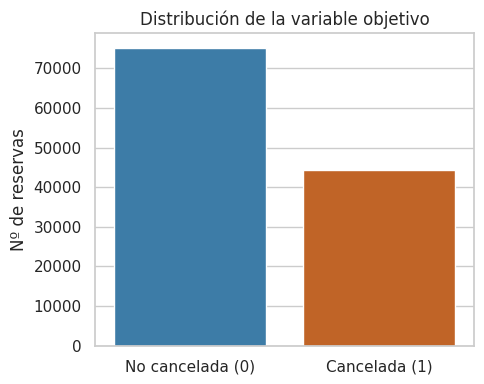

In [4]:
conteo = df['is_canceled'].value_counts().sort_index()
prop = df['is_canceled'].value_counts(normalize=True).sort_index()
print('Conteo:\n', conteo)
print('\nProporción:\n', prop.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='is_canceled', data=df, ax=ax, palette=['#2c7fb8', '#d95f0e'])
ax.set_xticklabels(['No cancelada (0)', 'Cancelada (1)'])
ax.set_title('Distribución de la variable objetivo')
ax.set_xlabel(''); ax.set_ylabel('Nº de reservas')
plt.tight_layout(); plt.show()

**Observación.** Alrededor del **37 % de las reservas se cancelan**. Es un **desbalance moderado**. Dos consecuencias para el diseño:

- Usaremos una **partición estratificada**: al dividir en entrenamiento y prueba, mantendremos ese 37 % en ambas partes.
- Elegiremos **ROC-AUC** como métrica principal (no la *accuracy*), porque la *accuracy* engaña con clases desbalanceadas: un modelo que dijera "nunca se cancela" ya acertaría el 63 %.

## 3. Valores ausentes (huecos en los datos)

Un **valor ausente** (o *nulo*, *NaN* = *Not a Number*) es una celda vacía. Necesitamos saber cuántos hay y en qué columnas para decidir si **rellenarlos** (*imputar*) o **descartar** la columna.

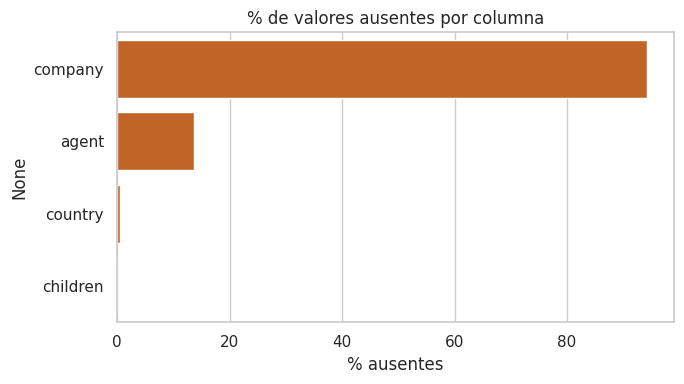

company     94.31
agent       13.69
country      0.41
children     0.00
dtype: float64

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color='#d95f0e')
ax.set_title('% de valores ausentes por columna')
ax.set_xlabel('% ausentes'); plt.tight_layout(); plt.show()
missing.round(2)

**Decisiones.**
- `company` está vacía en ~**94 %** de las filas → la **eliminamos** (apenas aporta información).
- `agent` (~14 %) es un identificador de agencia: la tratamos como **categoría** y marcamos los huecos como `"Unknown"` (desconocido).
- `country` (~0.4 %) y `children` (residual) se **imputan** (rellenan).

## 4. Fuga de información (*data leakage*) — ¡muy importante!

La **fuga de información** (*data leakage*) es un error grave: ocurre cuando el modelo usa, sin querer, datos que **revelan la respuesta** o que **no existirían en el momento real de predecir**. El modelo parecería buenísimo... pero estaría haciendo trampa.

Sospechamos de `reservation_status` (estado final de la reserva). Lo comprobamos con una **tabla cruzada** (cuenta combinaciones de dos columnas):

In [6]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


**Confirmado.** `reservation_status = 'Canceled'` coincide **exactamente** con `is_canceled = 1` (y `No-Show` también es una cancelación). Esta columna *es* la respuesta. Si la dejásemos, el modelo acertaría ~100 % de forma **engañosa e inútil**. Por eso `src/config.py` la incluye en `LEAKAGE_COLUMNS` y se **elimina siempre** (junto con `reservation_status_date`).

## 5. Variables numéricas

Las variables **numéricas** son números con los que se puede operar. `describe()` resume su estadística básica (media, mínimo, máximo, percentiles).

In [7]:
# En el EDA exploramos TODAS las numéricas candidatas, incluida `arrival_date_year`.
# OJO: `arrival_date_year` NO se usa como característica (no está en
# config.NUMERIC_COLUMNS); la analizamos aquí para JUSTIFICAR por qué la
# descartamos (ver la subsección 5.3, tras la matriz de correlación).
num = [c for c in config.NUMERIC_COLUMNS if c in df.columns]
if 'arrival_date_year' in df.columns and 'arrival_date_year' not in num:
    num = ['arrival_date_year'] + num
df[num].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0
is_repeated_guest,119390.0,0.03,0.18,0.00,0.00,0.00,0.0,1.0


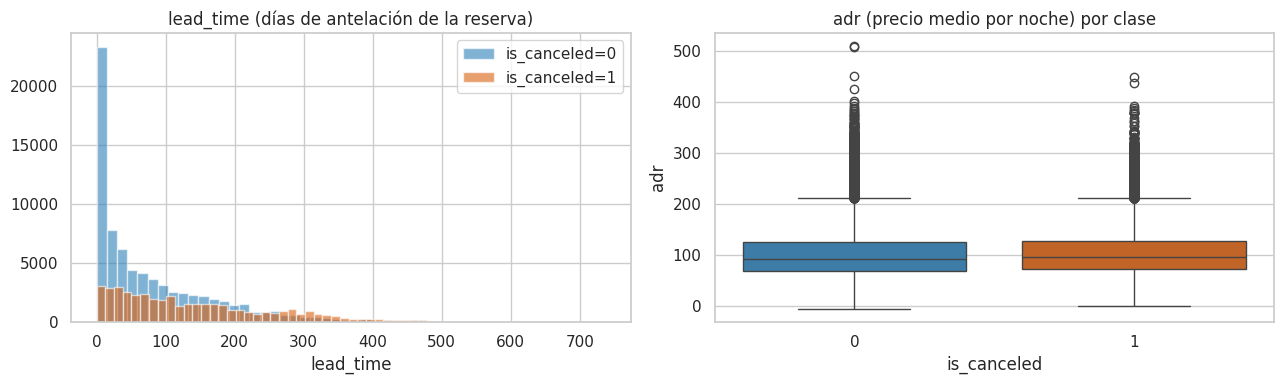

In [8]:
# Comparamos cómo se distribuyen dos variables según si la reserva se canceló
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls, color in zip([0, 1], ['#2c7fb8', '#d95f0e']):
    sub = df[df['is_canceled'] == cls]['lead_time']
    axes[0].hist(sub, bins=50, alpha=0.6, label=f'is_canceled={cls}', color=color)
axes[0].set_title('lead_time (días de antelación de la reserva)')
axes[0].set_xlabel('lead_time'); axes[0].legend()

sns.boxplot(x='is_canceled', y='adr', data=df[df['adr'] < 1000], ax=axes[1],
            palette=['#2c7fb8', '#d95f0e'])
axes[1].set_title('adr (precio medio por noche) por clase')
plt.tight_layout(); plt.show()

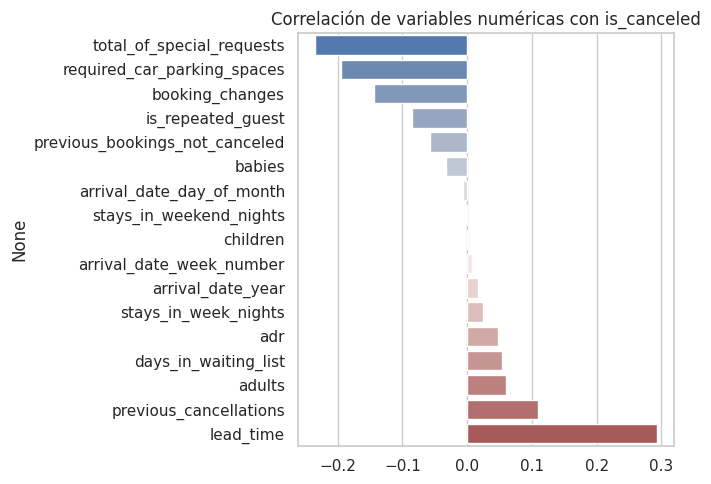

In [9]:
# 'Correlación' = en qué medida dos variables se mueven juntas (de -1 a +1).
# Aquí, la de cada numérica con el target: positiva = a más valor, más cancela.
corr = df[num + ['is_canceled']].corr()['is_canceled'].drop('is_canceled')
corr = corr.sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=corr.values, y=corr.index, ax=ax, palette='vlag')
ax.set_title('Correlación de variables numéricas con is_canceled')
plt.tight_layout(); plt.show()

**Lectura.** `lead_time` se relaciona **positivamente** con la cancelación (reservar con mucha antelación → más probabilidad de cancelar). En cambio, `total_of_special_requests` y `required_car_parking_spaces` se relacionan al **revés**: son señales de un cliente más comprometido, que cancela menos.

*(Nota: las variables están en escalas muy distintas — `lead_time` en cientos, `adr` en decenas — por eso luego las **estandarizaremos** a una escala común.)*

### Relaciones entre variables: *pairplot*

Hasta ahora hemos mirado las variables **de una en una**. Un **pairplot** (gráfico de pares) las enfrenta **todas contra todas**: en la diagonal, la distribución de cada variable; fuera de ella, un *scatter* (nube de puntos) de cada par. Al **colorear por la clase** (`is_canceled`) vemos de un vistazo qué pares de variables ayudan a **separar** las cancelaciones de las no cancelaciones.

Usamos solo unas pocas numéricas clave y una **muestra de 2 000 reservas** (dibujar 119 000 puntos sería ilegible y lentísimo).

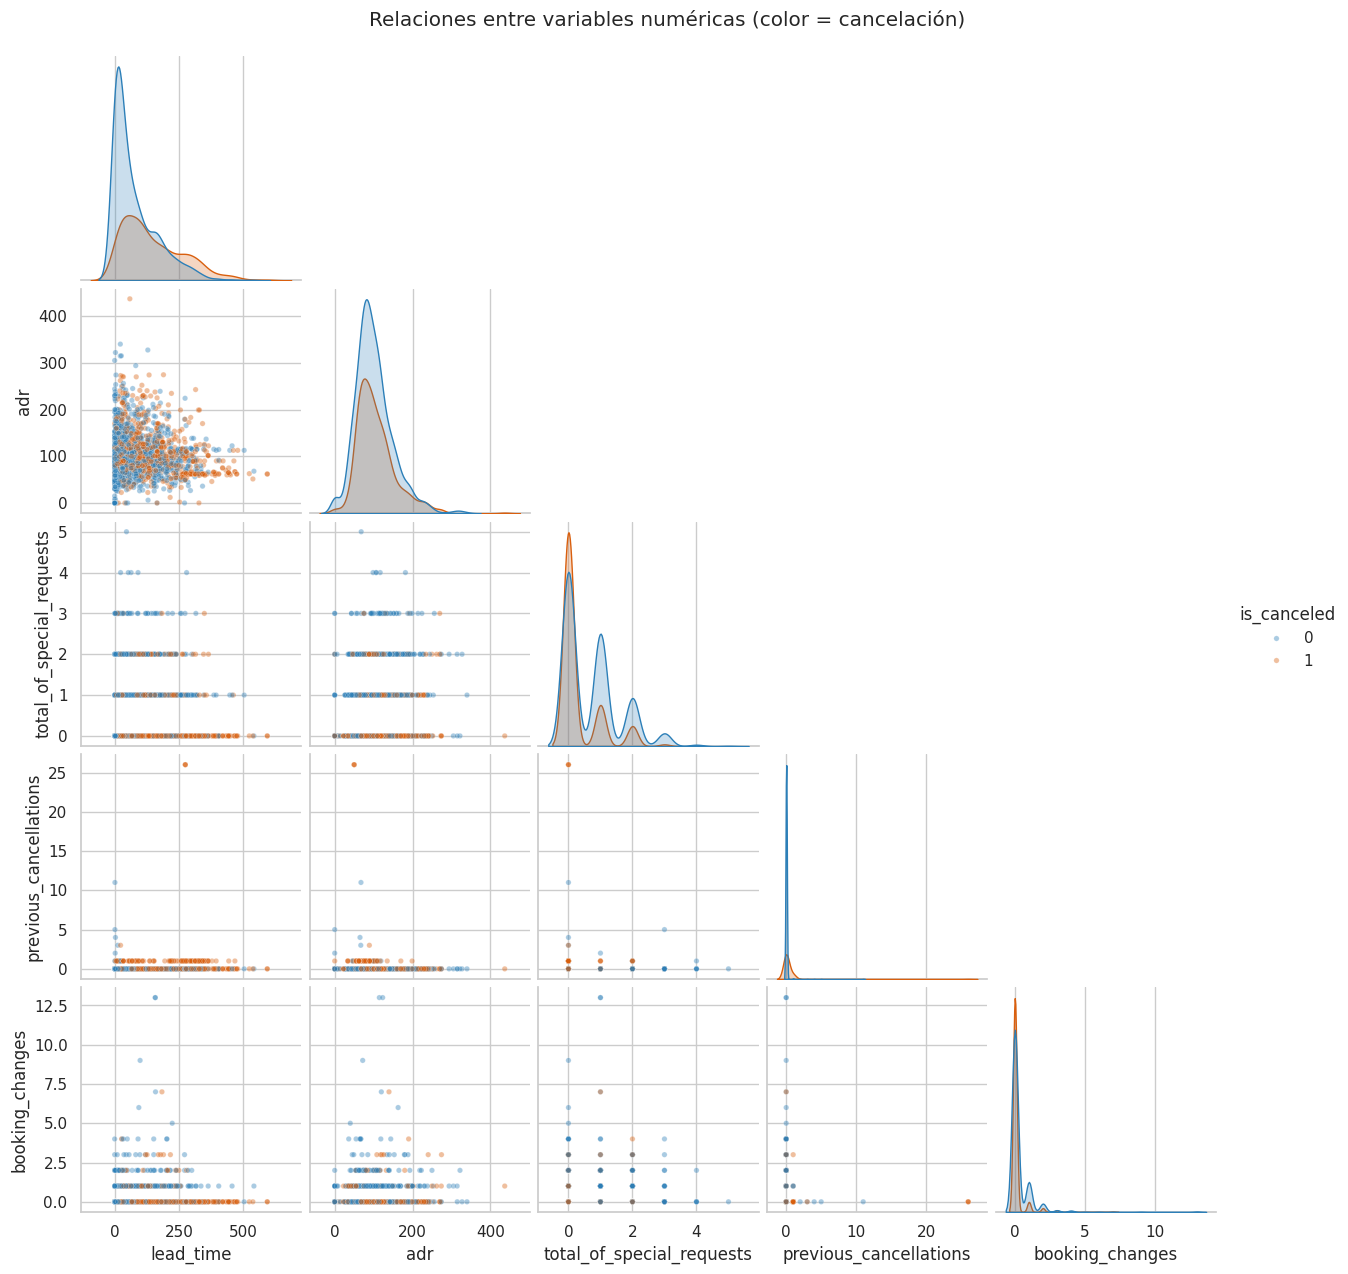

In [10]:
# Pairplot: enfrenta las numéricas clave entre sí, coloreando por la clase.
# Submuestreamos (119k filas serían inmanejables) y usamos corner=True para
# mostrar solo medio triángulo y reducir el desorden visual.
vars_clave = ['lead_time', 'adr', 'total_of_special_requests',
              'previous_cancellations', 'booking_changes']
muestra = df.sample(2000, random_state=42)
g = sns.pairplot(muestra[vars_clave + ['is_canceled']], hue='is_canceled',
                 palette=['#2c7fb8', '#d95f0e'], corner=True,
                 plot_kws=dict(alpha=0.4, s=15))
g.fig.suptitle('Relaciones entre variables numéricas (color = cancelación)', y=1.02)
plt.show()

**Lectura.** Las nubes naranja (cancelada) y azul (no cancelada) se solapan mucho: **ninguna pareja de variables, por sí sola, separa limpiamente** las clases. Esto es habitual y justifica usar modelos capaces de combinar muchas variables a la vez (árboles, *boosting*, redes) en lugar de reglas simples. Aun así se intuye que las cancelaciones tienden a concentrarse en `lead_time` alto y en `total_of_special_requests` = 0, coherente con la correlación con el *target* que vimos antes.

### Matriz de correlación: ¿hay variables redundantes?

La **correlación** mide de −1 a +1 cómo se mueven juntas dos variables. Si dos están **muy correlacionadas** (cerca de +1 o −1) aportan **casi la misma información**, y podríamos **descartar una** para simplificar el modelo sin perder casi nada. La matriz muestra ese valor para **cada par** de variables numéricas (pintamos solo el triángulo inferior para no repetir).

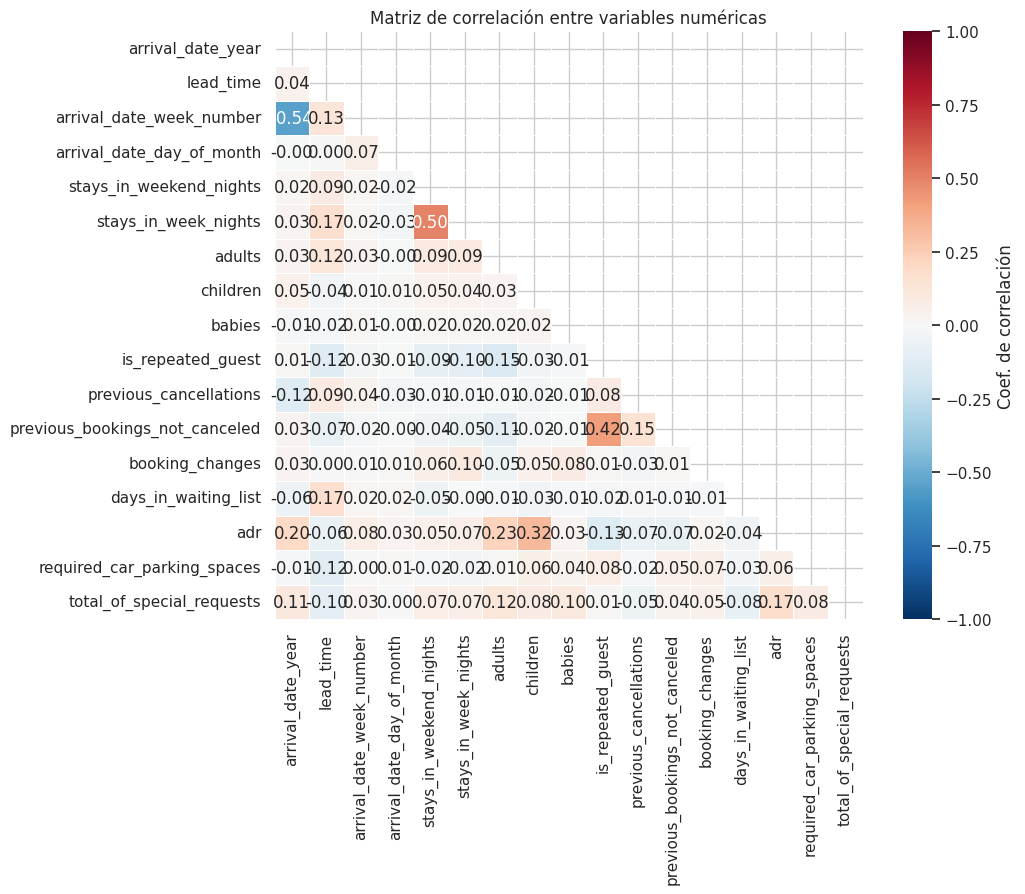

In [11]:
# Matriz de correlación entre las variables numéricas.
corr = df[num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # ocultar triángulo superior
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'label': 'Coef. de correlación'}, ax=ax)
ax.set_title('Matriz de correlación entre variables numéricas')
plt.tight_layout(); plt.show()

**Lectura.** En nuestro caso **no hay parejas fuertemente redundantes**: el valor más alto en magnitud es entre `arrival_date_year` y `arrival_date_week_number` (≈ **−0.54**), una correlación solo *moderada*. **Conclusión:** no eliminamos ninguna numérica por *redundancia* (ningún par alcanza |correlación| ≈ 0.9). Ahora bien, ese −0.54 es la pista de un problema **distinto** con `arrival_date_year`, que analizamos a continuación.

### 5.3. Una variable temporal que descartamos: `arrival_date_year`

De las cuatro fechas de llegada (`year`, `month`, `week_number`, `day_of_month`), las tres últimas aportan **estacionalidad** (épocas del año con más o menos cancelaciones), pero el **año** no aporta valor real. El −0.54 con `week_number` que acabamos de ver es la primera señal: nace de que el dataset cubre **años parciales**. Lo comprobamos:

In [12]:
# Evidencia para decidir sobre `arrival_date_year`:
# (1) tasa de cancelación por año y (2) qué meses cubre cada año.
meses = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']
tasa = df.groupby('arrival_date_year')['is_canceled'].agg(['size', 'mean']).round(4)
tasa.columns = ['n_reservas', 'tasa_cancelacion']
print('Tasa de cancelación por año:')
print(tasa.to_string())
print('\nMeses cubiertos por cada año:')
for anio, sub in df.groupby('arrival_date_year'):
    presentes = sorted(set(sub['arrival_date_month']), key=meses.index)
    print(f'  {anio}: {len(presentes):2d} meses -> {presentes}')

Tasa de cancelación por año:
                   n_reservas  tasa_cancelacion
arrival_date_year                              
2015                    21996            0.3702
2016                    56707            0.3586
2017                    40687            0.3870

Meses cubiertos por cada año:
  2015:  6 meses -> ['July', 'August', 'September', 'October', 'November', 'December']
  2016: 12 meses -> ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
  2017:  8 meses -> ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']


**Decisión: eliminar `arrival_date_year`.** Tres motivos:

1. **Apenas discrimina:** la tasa de cancelación es casi idéntica los tres años (≈ 37 %, 36 %, 39 %).
2. **No generaliza:** el modelo debe puntuar reservas *futuras*. Un año no visto al entrenar (2018 en adelante) no tiene un valor de "año" interpretable (los árboles lo meterían en el último tramo conocido; un modelo lineal extrapolaría una tendencia inexistente).
3. **Va confundido con la estación:** como se ve arriba, **2015 solo cubre jul–dic y 2017 solo ene–ago** (años parciales); de ahí el −0.54 con `week_number`. Esa señal estacional ya la recogen `month` y `week_number`, que **sí se repiten** cada año.

En una partición *aleatoria*, incluir el año subía el ROC-AUC de XGBoost ~0.003, pero es una mejora **engañosa**: desaparecería al predecir el futuro (ver la limitación de *validación temporal* del informe). Por eso `arrival_date_year` **no** figura en `config.NUMERIC_COLUMNS` y el preprocesador la descarta.

## 6. Variables categóricas y tasa de cancelación

Las variables **categóricas** son etiquetas de texto (tipo de hotel, país...). Para cada una calculamos su **tasa de cancelación** (qué porcentaje de sus reservas se cancela), que nos dice si es útil para predecir.

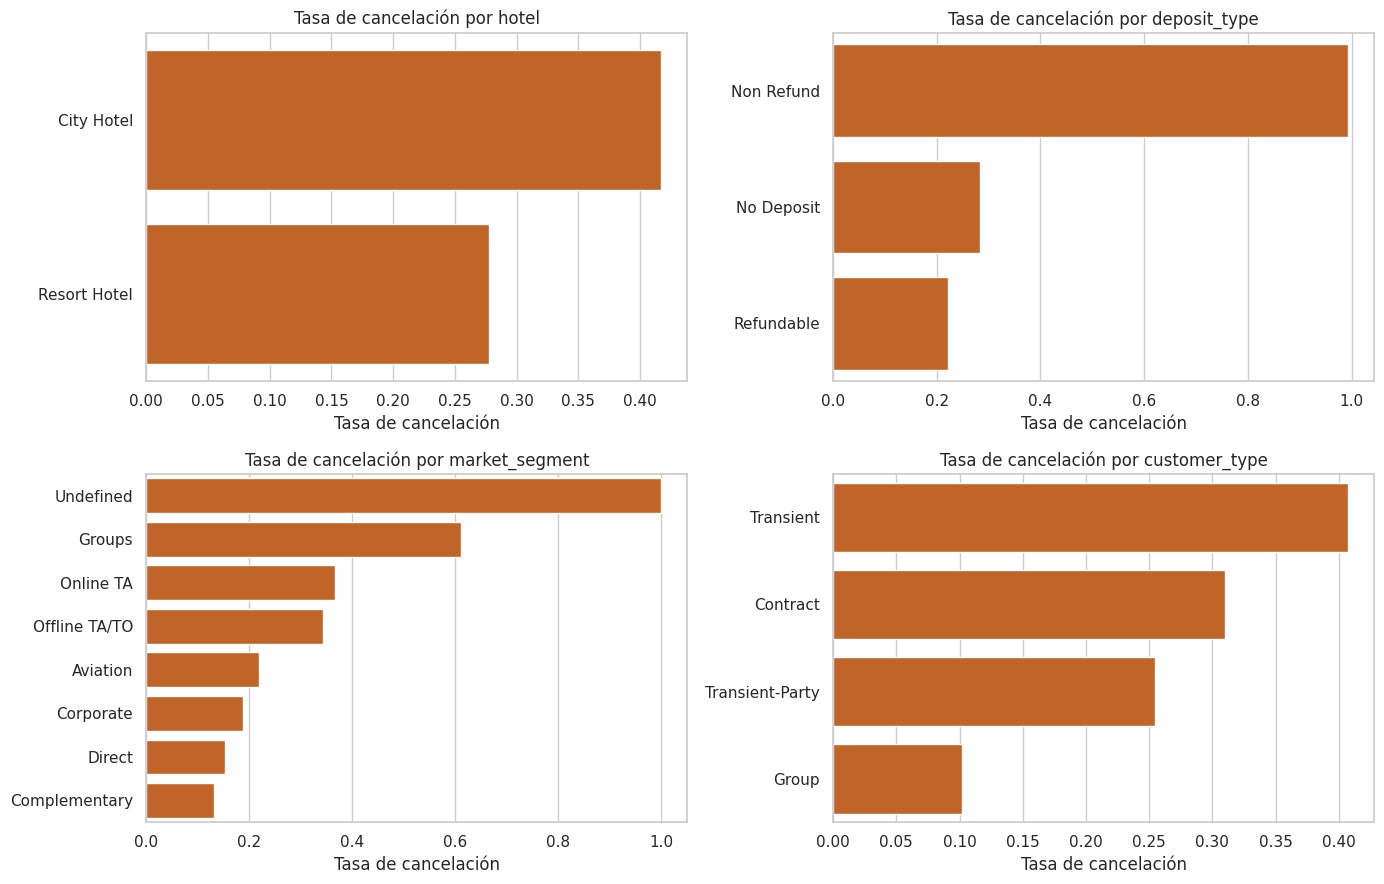

In [13]:
def tasa_cancelacion(col, ax):
    # media de is_canceled por categoría = proporción de cancelaciones
    tasa = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax, color='#d95f0e')
    ax.set_title(f'Tasa de cancelación por {col}')
    ax.set_xlabel('Tasa de cancelación'); ax.set_ylabel('')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, ax in zip(['hotel', 'deposit_type', 'market_segment', 'customer_type'], axes.ravel()):
    tasa_cancelacion(col, ax)
plt.tight_layout(); plt.show()

**Hallazgos clave.**
- `deposit_type = 'Non Refund'` (depósito no reembolsable) tiene una tasa de cancelación **altísima** (~99 %): es la variable más predictiva... **pero al revés de lo que parece** (lo explicamos justo debajo).
- El *City Hotel* cancela más que el *Resort Hotel*.
- Los segmentos `Groups` y `Offline TA/TO` cancelan más que `Direct`/`Corporate`.
- El cliente `Transient` (suelto) cancela más que `Contract`/`Group`.

### 🔎 ¿Por qué un depósito *no reembolsable* predice cancelación? (parece lo contrario)

A primera vista no tiene sentido: si el depósito **no se devuelve**, esperaríamos que el cliente **no cancele** (perdería su dinero). Pero en estos datos ocurre lo contrario y de forma extrema (~99 %). La clave no es el comportamiento del cliente, sino **qué tipo de reserva lleva esa etiqueta**. Vamos a mirarlo:

In [14]:
# ¿QUIÉN hace las reservas 'Non Refund'? Su perfil explica la paradoja.
nr = df[df['deposit_type'] == 'Non Refund']
resto = df[df['deposit_type'] != 'Non Refund']
print(f"'Non Refund': {len(nr):,} reservas  |  tasa de cancelación = {nr['is_canceled'].mean():.1%}\n")
print('Perfil de esas reservas:')
print(f"  - País principal     : {nr['country'].mode().iloc[0]} "
      f"({(nr['country'] == 'PRT').mean():.0%} son de Portugal)")
print(f"  - Canal principal    : {nr['distribution_channel'].mode().iloc[0]} "
      f"({(nr['distribution_channel'] == 'TA/TO').mean():.0%} vía agencia / turoperador)")
print(f"  - Segmento principal : {nr['market_segment'].mode().iloc[0]} "
      f"(Groups + Offline TA/TO = {nr['market_segment'].isin(['Groups', 'Offline TA/TO']).mean():.0%})")
print(f"  - Antelación (lead_time) mediana: {nr['lead_time'].median():.0f} días "
      f"(frente a {resto['lead_time'].median():.0f} del resto)")

'Non Refund': 14,587 reservas  |  tasa de cancelación = 99.4%

Perfil de esas reservas:
  - País principal     : PRT (97% son de Portugal)
  - Canal principal    : TA/TO (94% vía agencia / turoperador)
  - Segmento principal : Groups (Groups + Offline TA/TO = 97%)
  - Antelación (lead_time) mediana: 183 días (frente a 57 del resto)


**Lectura del perfil.** Esas reservas no son un cliente cualquiera reaccionando a una política de depósito; son **un patrón operativo muy concreto**:

- Casi todas (~97 %) son de **Portugal**, hechas a través de **agencias / turoperadores** (canal *TA/TO*), en su mayoría **grupos** y **agencias offline**, y con **mucha antelación** (mediana ~183 días, frente a ~57 del resto).
- Es el patrón típico de las **reservas en bloque / cupos** que las agencias y turoperadores hacen *especulativamente* (reservan habitaciones por adelantado para revenderlas); las que no consiguen colocar se liberan → quedan registradas como **canceladas**.
- Además, `is_canceled` incluye los **no-shows** (no presentarse). En una reserva no reembolsable, si el cliente no aparece el hotel **se queda el dinero** y no tiene por qué reclamar nada: simplemente queda anotada como cancelación.

**La idea clave (correlación ≠ causalidad).** El modelo **no** aprende que "un depósito no reembolsable *causa* cancelaciones". Aprende que esa etiqueta **identifica casi con certeza** ese perfil de reserva (Portugal + agencia + grupo + mucha antelación) que casi siempre se anula. `deposit_type = 'Non Refund'` funciona como un **indicador casi determinista** de ese perfil; por eso domina la importancia de variables.

**Dos matices importantes:**
- **No es fuga de información** (*data leakage*): a diferencia de `reservation_status`, esta variable se conoce **en el momento de reservar**, así que usarla es legítimo.
- **Puede no generalizar**: en otro hotel donde "Non Refund" signifique tarifas prepagadas que los clientes **sí respetan**, la regla aprendida (`Non Refund ⇒ cancela`) sería falsa. Es un patrón propio del **proceso de reservas de estos hoteles**, no una ley universal.

> 📖 *Fuga de información*, *one-hot* y demás términos están en `docs/glosario.md`.

## 7. Conclusiones del EDA → decisiones de modelado

Todo lo aprendido se traduce en decisiones concretas dentro del código:

| Hallazgo | Decisión en el código |
|---|---|
| `reservation_status*` revelan la respuesta (*fuga*) | Eliminar (`LEAKAGE_COLUMNS`) |
| `company` ~94 % de huecos | Eliminar (`DROP_COLUMNS`) |
| `arrival_date_year` no generaliza (años parciales, confundida con la estación) | **Excluir** de las características (`NUMERIC_COLUMNS`) |
| `agent` es un ID con huecos | Tratar como categoría; huecos → `Unknown` |
| Huecos en `country`, `children` | Imputar (rellenar) |
| Variables en escalas muy distintas | Estandarizar (`StandardScaler`) |
| Categóricas de alta cardinalidad (`country`, `agent`) | One-hot con límite de categorías |
| Clases desbalanceadas (~37 %) | Partición **estratificada** + métrica **ROC-AUC** |
| Reservas con 0 huéspedes | Eliminar (datos erróneos) |

Estas decisiones están implementadas en `src/data_loader.py` y `src/preprocessing.py`. Cada modelo se estudia a fondo en su propio notebook (`02`–`06`) y todos se comparan en `07_comparativa_modelos.ipynb`.